# Otter Hydraulic System — Condition Monitoring Notebook #1 (Read in Data)

The Otter field has 5 wells and is a 27km tie back to the Eider platform

This notebook ingests 24 annual hydraulic control system raw CSV files (2020–2024), converts them to Parquet for efficient storage and processing, concatenates into a single multi-year DataFrame, and performs basic plots check on the combined data.

**Tasks**
- Read annual CSV files (retrieved from Pi Processbook) with raw data from **2020–2024**  
- Convert each year to **Parquet** (reduce size, faster read/write)  
- Concatenate annual DataFrames into **one** DataFrame  
- Display sample rows/summary to **verify multi-year coverage**
- Smooths the tank levles whoich exhbit some nopise





<img src="Eider Platform.png" alt="Otter logo" width="280" align="left" style="margin-right: 15px; border-radius: 8px;">


In [ ]:
# Read in the raw .csv files and convert to parquet. There is 1 csv file per year for 20 years.

import pandas as pd
import os

# Define Otter raw data folder
folder = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B"
output_folder = os.path.join(folder, "Parquet_Clean_Output")
os.makedirs(output_folder, exist_ok=True)

# Define valve/categorical columns (update as needed for otter tags)
valve_columns = [
    'P1_PMV', 'P1_PWV', 'P1_AMV', 'P1_SCSSV', 'P1_PDV', 'P1_TDV',
    'P2_PMV', 'P2_PWV', 'P2_AMV', 'P2_SCSSV', 'P2_PDV', 'P2_TDV',
    'P3_PMV', 'P3_PWV', 'P3_AMV', 'P3_SCSSV', 'P3_PDV', 'P3_TDV',
    'I1_PMV', 'I1_PWV', 'I1_AMV',
    'I2_PMV', 'I2_PWV', 'I2_AMV',
    'MPMV_Inlet','Man_CI','SCM1_LP1_COV','SCM1_HP_COV','SCM2_LP1_COV','SCM2_HP_COV','SCM3_LP1_COV','SCM3_HP_COV','SCM4_LP1_COV','SCM4_HP_COV','SCM5_LP1_COV','SCM5_HP_COV'
]

# PCV/WCV columns to clean
pcv_columns = ['FCV_CALC','FCV_CPI','P1_PCV','P2_PCV','P3_PCV','I1_PCV','I2_PCV']

# Process Excel files and convert to Parquet format
for file in sorted(os.listdir(folder)):
    if file.endswith(".xlsx"):
        file_path = os.path.join(folder, file)
        print(f"\n📁 Processing file: {file}")

        try:
            xls = pd.ExcelFile(file_path)
            for sheet in xls.sheet_names:
                print(f"   🔄 Reading sheet: {sheet}")
                
                try:
                    # Step 1: Read + clean
                    df = pd.read_excel(file_path, sheet_name=sheet, skiprows=8)
                    df = df.drop(index=0).reset_index(drop=True)
                    df = df.replace("I/O Timeout", pd.NA)

                    # Remove unnamed columns
                    df.columns = [col if "Unnamed" not in str(col) else pd.NA for col in df.columns]
                    df = df.loc[:, df.columns.notna()]

                    # Standardize timestamp
                    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
                    df.rename(columns={df.columns[0]: "Timestamp"}, inplace=True)

                    # Convert all but valve columns to numeric
                    for col in df.columns:
                        if col != 'Timestamp' and col not in valve_columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')

                    # Explicit cleanup of PCV/WCV
                    for pcv_col in pcv_columns:
                        if pcv_col in df.columns:
                            print(f"      🛠️ Cleaning '{pcv_col}'")
                            invalid_count = df[pcv_col][~df[pcv_col].astype(str).str.replace('.', '', 1).str.isnumeric()].count()
                            df[pcv_col] = pd.to_numeric(df[pcv_col], errors='coerce')
                            print(f"         ⚠️ Non-numeric entries coerced: {invalid_count}")

                    # Save to Parquet
                    base_name = os.path.splitext(file)[0]
                    out_name = f"{base_name}_{sheet}_clean.parquet_pcv" 
                    out_path = os.path.join(output_folder, out_name)
                    df.to_parquet(out_path, index=False)
                    print(f"      ✅ Saved: {out_name}")

                except Exception as e:
                    print(f"      ❌ Failed to process sheet '{sheet}': {e}")
        
        except Exception as e:
            print(f"❌ Failed to open {file}: {e}")



📁 Processing file: Otter 2003 to 2004.xlsx
   🔄 Reading sheet: Sheet1
      🛠️ Cleaning 'FCV_CALC'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'FCV_CPI'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P1_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P2_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P3_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'I1_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'I2_PCV'
         ⚠️ Non-numeric entries coerced: 0
      ✅ Saved: Otter 2003 to 2004_Sheet1_clean.parquet_pcv

📁 Processing file: Otter 2004 to 2005.xlsx
   🔄 Reading sheet: Sheet1
      🛠️ Cleaning 'FCV_CALC'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'FCV_CPI'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P1_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P2_PCV'
         ⚠️ Non-numeric entries coerced: 0
      🛠️ Cleaning 'P3_P

In [ ]:
#Remove Padding from data


# Folder containing Otter parquet files
folder_path = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output"

for filename in os.listdir(folder_path):
    if filename.endswith(".parquet_pcv"):
        filepath = os.path.join(folder_path, filename)
        print(f"\n📄 Processing: {filename}")
        try:
            # Read parquet
            df = pd.read_parquet(filepath)

            # Remove rows with missing Timestamp
            if 'Timestamp' in df.columns:
                df_clean = df[df['Timestamp'].notna()]
            else:
                print("⚠️ 'Timestamp' column missing; skipping cleanup.")
                continue

            # Overwrite the file with cleaned version
            df_clean.to_parquet(filepath, index=False)

            # Summary
            print(f"   ✅ Cleaned and saved: {filename}")
            print(f"   Rows kept: {len(df_clean)} / Original: {len(df)}")

        except Exception as e:
            print(f"❌ Error reading {filename}: {e}")


📄 Processing: Otter 2003 to 2004_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2003 to 2004_Sheet1_clean.parquet_pcv
   Rows kept: 527041 / Original: 715201

📄 Processing: Otter 2004 to 2005_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2004 to 2005_Sheet1_clean.parquet_pcv
   Rows kept: 525601 / Original: 715201

📄 Processing: Otter 2005 to 2006_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2005 to 2006_Sheet1_clean.parquet_pcv
   Rows kept: 525601 / Original: 715201

📄 Processing: Otter 2006 to 2007_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2006 to 2007_Sheet1_clean.parquet_pcv
   Rows kept: 525601 / Original: 715201

📄 Processing: Otter 2007 to 2008_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2007 to 2008_Sheet1_clean.parquet_pcv
   Rows kept: 527041 / Original: 715201

📄 Processing: Otter 2008 to 2009_Sheet1_clean.parquet_pcv
   ✅ Cleaned and saved: Otter 2008 to 2009_Sheet1_clean.parquet_pcv
   Rows kept: 525601 / Original: 71520

In [ ]:
#Concatenate each of the Annual files data  into 1 parquet format data set

import pandas as pd
from pathlib import Path
import re

# Folder with cleaned parquet files
parquet_folder = Path(r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output")

# Get all parquet files
parquet_files = list(parquet_folder.glob("*.parquet_pcv"))

# Function to extract starting year from filename
def extract_year(filepath):
    match = re.search(r'Otter Data (\d{4})', filepath.name)
    return int(match.group(1)) if match else float('inf')  # Put unmatched files at end

# Sort files by extracted year
parquet_files_sorted = sorted(parquet_files, key=extract_year)

# Load and combine
df_list = []
for file in parquet_files_sorted:
    print(f"📄 Reading: {file.name}")
    df = pd.read_parquet(file)
    df_list.append(df)

# Concatenate all into a single DataFrame
df_all_otter2 = pd.concat(df_list, ignore_index=True)

# Optional: show preview
print(f"\n✅ Combined shape: {df_all_otter2.shape}")
print(df_all_otter2.head())


📄 Reading: Otter 2003 to 2004_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2004 to 2005_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2005 to 2006_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2006 to 2007_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2007 to 2008_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2008 to 2009_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2009 to 2010_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2010 to 2011_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2011 to 2012_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2012 to 2013_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2013 to 2014_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2014 to 2015_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2015 to 2016_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2016 to 2017_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2017 to 2018_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2018 to 2019_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2019 to 2020_Sheet1_clean.parquet_pcv
📄 Reading: Otter 2020 to 2021_Sheet1_clean.parquet_pcv
📄 Reading:

In [ ]:
# Combined DataFrame
df_all_otter2 = pd.concat(df_list, ignore_index=True)

# ✅ Preview first and last rows
print("\n🔹 Head (first 5 rows):")
print(df_all_otter2.head())

print("\n🔹 Tail (last 5 rows):")
print(df_all_otter2.tail())

# ✅ Show DataFrame structure
print("\n🔹 DataFrame Info:")
print(df_all_otter2.info())


🔹 Head (first 5 rows):
            Timestamp  HPU_SPLY_LEV  HPU-RET_LEV  HPU_LP_A_SPLY  \
0 2003-05-01 00:00:00     53.161541    40.324402     306.491394   
1 2003-05-01 00:01:00     53.158562    40.324211     306.491058   
2 2003-05-01 00:02:00     53.155582    40.324017     306.490723   
3 2003-05-01 00:03:00     53.152603    40.323826     306.490387   
4 2003-05-01 00:04:00     53.149628    40.323631     306.490051   

   HPU_LP_B_SPLY  HPU_HP_A_SPLY  HPU_HP_B_SPLY  HPU_LPA_OUT  HPU_LPB_OUT  \
0     304.333710     640.333679     638.738098   200.871704   203.505295   
1     304.328003     638.671509     637.490540   200.877396   203.506134   
2     304.322296     637.009399     636.242981   200.883087   203.506958   
3     304.316559     635.347229     634.995422   200.888779   203.507797   
4     304.310852     633.685059     633.747864   200.894470   203.508636   

   HPU_HPA_OUT  ...  SCM5_HP_COV  SCM3_LP_CONS  SCM3_HP_CONS  SCM3_RET  \
0   498.880890  ...          HP1         2

In [ ]:
output_path = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet"
df_all_otter2.to_parquet(output_path, index=False)
print(f"✅ Saved combined data to: {output_path}")


✅ Saved combined data to: C:\Users\rosst\OneDrive\Control Integrity\Data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet


In [ ]:
import pandas as pd

# 1) Specify the path to your Parquet file
input_path =  r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet"

# 2) Read it into memory
#    – pandas will auto-detect the Parquet engine (pyarrow or fastparquet), 
#      but you can force one if you like:
df_otter = pd.read_parquet(input_path, engine="pyarrow")

# 3) (Optional) Quick sanity check
print(f"✅ Loaded DataFrame with {df_otter.shape[0]} rows and {df_otter.shape[1]} columns")
print(df_otter.head())


✅ Loaded DataFrame with 11046261 rows and 87 columns
            Timestamp  HPU_SPLY_LEV  HPU-RET_LEV  HPU_LP_A_SPLY  \
0 2003-05-01 00:00:00     53.161541    40.324402     306.491394   
1 2003-05-01 00:01:00     53.158562    40.324211     306.491058   
2 2003-05-01 00:02:00     53.155582    40.324017     306.490723   
3 2003-05-01 00:03:00     53.152603    40.323826     306.490387   
4 2003-05-01 00:04:00     53.149628    40.323631     306.490051   

   HPU_LP_B_SPLY  HPU_HP_A_SPLY  HPU_HP_B_SPLY  HPU_LPA_OUT  HPU_LPB_OUT  \
0     304.333710     640.333679     638.738098   200.871704   203.505295   
1     304.328003     638.671509     637.490540   200.877396   203.506134   
2     304.322296     637.009399     636.242981   200.883087   203.506958   
3     304.316559     635.347229     634.995422   200.888779   203.507797   
4     304.310852     633.685059     633.747864   200.894470   203.508636   

   HPU_HPA_OUT  ...  SCM5_HP_COV  SCM3_LP_CONS  SCM3_HP_CONS  SCM3_RET  \
0   498.88089

In [ ]:
df_otter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11046261 entries, 0 to 11046260
Data columns (total 87 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Timestamp         datetime64[us]
 1   HPU_SPLY_LEV      float64       
 2   HPU-RET_LEV       float64       
 3   HPU_LP_A_SPLY     float64       
 4   HPU_LP_B_SPLY     float64       
 5   HPU_HP_A_SPLY     float64       
 6   HPU_HP_B_SPLY     float64       
 7   HPU_LPA_OUT       float64       
 8   HPU_LPB_OUT       float64       
 9   HPU_HPA_OUT       float64       
 10  HPU_HPB_OUT       float64       
 11  HPU_SSIV1_OUT     float64       
 12  HPU_SSIV2_OUT     float64       
 13  SCM1_LPA          float64       
 14  SCM1_LPB          float64       
 15  SCM1_LP_CONS      float64       
 16  SCM1_HPA          float64       
 17  SCM1_HPB          float64       
 18  SCM1_HP_CONS      float64       
 19  SCM1_RET          float64       
 20  SCM1_LP_FLOW      float64       
 21  SCM1_H

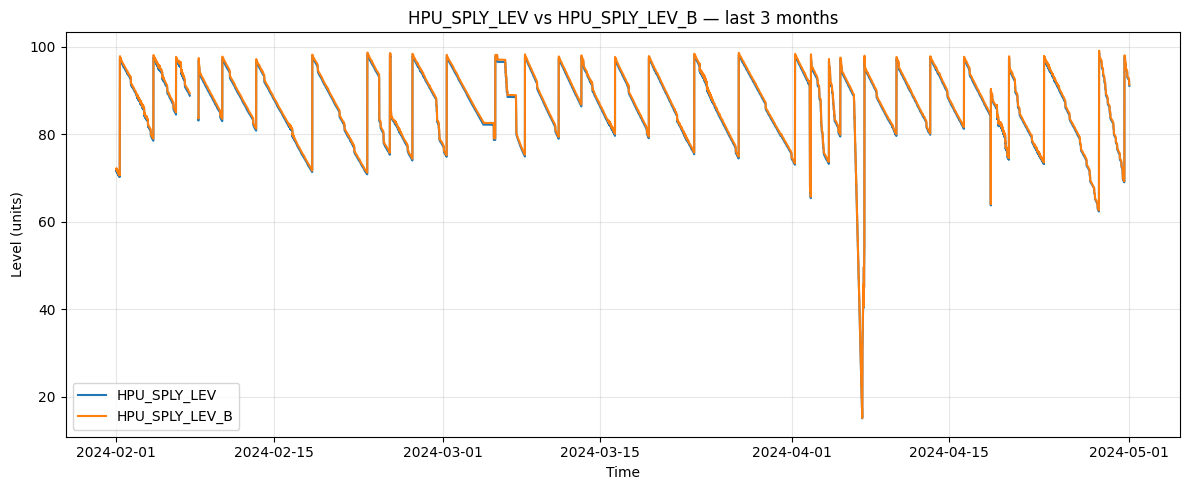

In [ ]:
# Plot tank levels to verify data

import pandas as pd
import matplotlib.pyplot as plt

def plot_two_supply_levels(df,
                           a='HPU_SPLY_LEV',
                           b='HPU_SPLY_LEV_B',
                           months=3,              # set to None for full history
                           resample='5T'):        # thin a bit for speed
    d = df.copy()

    # 1) Make sure time is the index
    if 'Timestamp' in d.columns:
        d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
        d = d.dropna(subset=['Timestamp']).set_index('Timestamp')
    else:
        d.index = pd.to_datetime(d.index, errors='coerce')
    d = d.sort_index()

    # 2) Keep just the two sensors (as numeric)
    for c in (a, b):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        else:
            raise KeyError(f"Column '{c}' not found")

    # 3) Slice last N months (optional)
    if months is not None:
        end = d.index.max()
        start = end - pd.DateOffset(months=months)
        d = d.loc[start:end, [a, b]]

    # 4) Optional light resample for smoother plot
    if resample:
        d = d.resample(resample).median()

    # 5) Plot
    plt.figure(figsize=(12,5))
    plt.plot(d.index, d[a], label=a)
    plt.plot(d.index, d[b], label=b)
    title = f"{a} vs {b} — last {months} months" if months else f"{a} vs {b}"
    plt.title(title)
    plt.xlabel("Time"); plt.ylabel("Level (units)"); plt.grid(True, alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

# usage:
plot_two_supply_levels(df_otter)                 # last 3 months
# plot_two_supply_levels(df_otter, months=None)  # full history


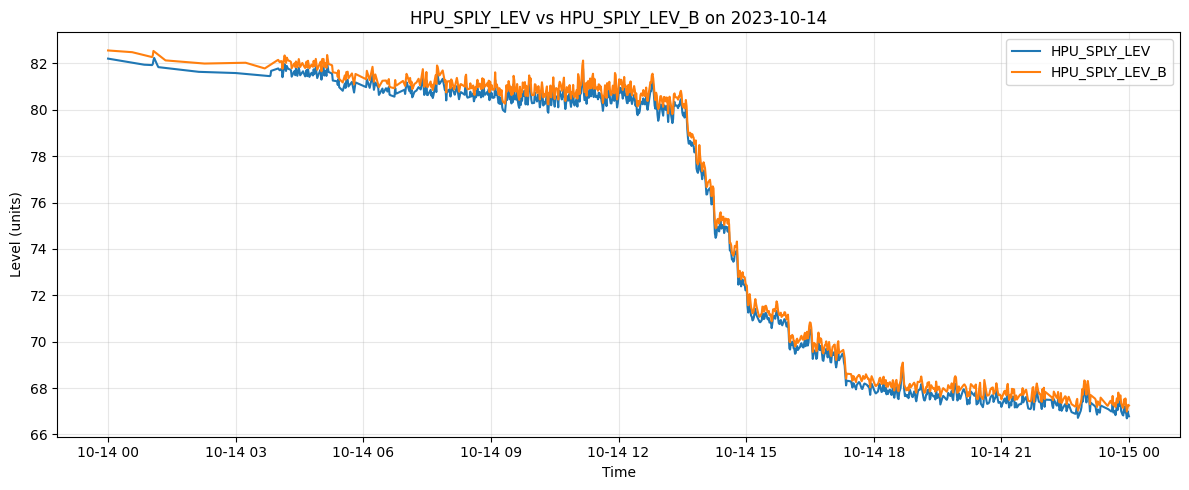

                     HPU_SPLY_LEV  HPU_SPLY_LEV_B
Timestamp                                        
2023-10-14 00:00:00     82.204224       82.555740
2023-10-14 00:01:00     82.198982       82.553589
2023-10-14 00:02:00     82.193741       82.551445
2023-10-14 00:03:00     82.188499       82.549294
2023-10-14 00:04:00     82.183258       82.547150


In [ ]:
# Dipslay a days tank levels where there is intermitent noise

def plot_two_supply_levels_for_day(df,
                                   a='HPU_SPLY_LEV',
                                   b='HPU_SPLY_LEV_B',
                                   day='2023-10-14',
                                   resample='1T'):   # thin a bit for speed
    d = df.copy()

    # 1) Make sure time is the index
    if 'Timestamp' in d.columns:
        d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
        d = d.dropna(subset=['Timestamp']).set_index('Timestamp')
    else:
        d.index = pd.to_datetime(d.index, errors='coerce')
    d = d.sort_index()

    # 2) Keep just the two sensors (as numeric)
    for c in (a, b):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        else:
            raise KeyError(f"Column '{c}' not found")

    # 3) Filter for the specific day
    start = pd.to_datetime(day)
    end = start + pd.Timedelta(days=1)
    d = d.loc[start:end, [a, b]]

    # 4) Optional resample
    if resample:
        d = d.resample(resample).median()

    # 5) Plot
    plt.figure(figsize=(12,5))
    plt.plot(d.index, d[a], label=a)
    plt.plot(d.index, d[b], label=b)
    plt.title(f"{a} vs {b} on {day}")
    plt.xlabel("Time"); plt.ylabel("Level (units)")
    plt.grid(True, alpha=0.3)
    plt.legend(); plt.tight_layout()
    plt.show()

    return d  # return the filtered DataFrame in case you want to inspect values


# usage:
filtered = plot_two_supply_levels_for_day(df_otter, day="2023-10-14")
print(filtered.head())


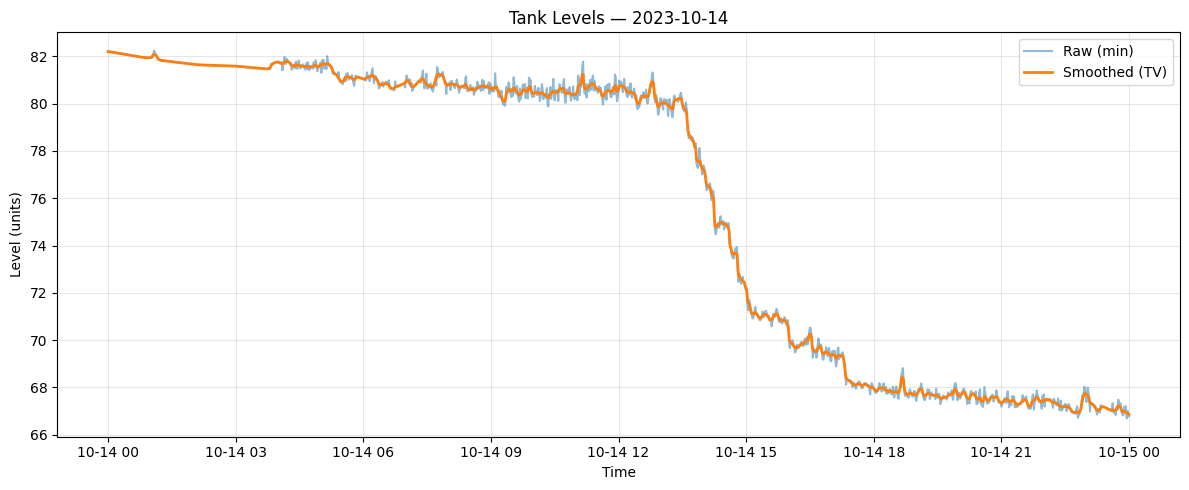

In [ ]:
# Trial Denoising tank level using Total Variation (TV) denoising

import matplotlib.pyplot as plt

# -------- Fallback TV denoise (Condat's fast 1D TV; pure NumPy) --------
def tv1d_denoise(y, lam):
    """Total variation denoising (L1, 1D). lam >= 0 controls smoothing."""
    n = len(y)
    if n == 0 or lam <= 0:
        return y.astype(float).copy()
    x = np.empty(n, dtype=float)
    k = k0 = 0
    vmin = y[0] - lam
    vmax = y[0] + lam
    umin = lam
    umax = -lam
    for i in range(1, n):
        d = y[i] - y[i-1]
        umin += d
        umax += d
        if umin > lam:
            while k <= i-1:
                x[k] = vmin
                k += 1
            k0 = i
            vmin = y[i] - lam
            vmax = y[i] + lam
            umin = lam
            umax = -lam
        elif umax < -lam:
            while k <= i-1:
                x[k] = vmax
                k += 1
            k0 = i
            vmin = y[i] - lam
            vmax = y[i] + lam
            umin = lam
            umax = -lam
        else:
            if umin < -lam:
                vmin += (umin + lam) / (i - k0 + 1)
                umin = -lam
            if umax > lam:
                vmax += (umax - lam) / (i - k0 + 1)
                umax = lam
    vbar = vmin + umin / (n - k0 + 1)
    while k <= n - 1:
        x[k] = vbar
        k += 1
    return x

# -------- Helper: prepare series & slice day --------
def _prepare_day(df, a='HPU_SPLY_LEV', b='HPU_SPLY_LEV_B', day='2023-10-14', combine='mean'):
    d = df.copy()
    if 'Timestamp' in d.columns:
        d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
        d = d.dropna(subset=['Timestamp']).set_index('Timestamp')
    else:
        d.index = pd.to_datetime(d.index, errors='coerce')
    d = d.sort_index()

    for c in (a, b):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        else:
            raise KeyError(f"Column '{c}' not found")

    if combine == 'min':
        d['level_raw'] = d[[a, b]].min(axis=1)
    else:
        d['level_raw'] = d[[a, b]].mean(axis=1)

    start = pd.to_datetime(day)
    end = start + pd.Timedelta(days=1)
    d = d.loc[start:end, ['level_raw']]
    d = d.dropna()
    return d

# -------- Main: TV smoothing for a given day --------
def plot_tv_smoothed_day(df, day='2023-10-14', a='HPU_SPLY_LEV', b='HPU_SPLY_LEV_B',
                         combine='mean', strength=0.4, use_skimage=True):
    """
    strength ~ TV lambda:
      - higher -> flatter plateaus (more smoothing)
      - lower  -> closer to raw
    combine: 'mean' or 'min'
    """
    d = _prepare_day(df, a=a, b=b, day=day, combine=combine)

    y = d['level_raw'].to_numpy().astype(float)

    y_smooth = None
    if use_skimage:
        try:
            from skimage.restoration import denoise_tv_chambolle
            # skimage uses 'weight' instead of lambda; map roughly
            y_smooth = denoise_tv_chambolle(y, weight=strength, channel_axis=None)
        except Exception:
            # Fallback to pure NumPy TV if skimage missing
            y_smooth = tv1d_denoise(y, lam=strength)
    else:
        y_smooth = tv1d_denoise(y, lam=strength)

    d['level_smooth'] = y_smooth

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(d.index, d['level_raw'], label=f"Raw ({combine})", alpha=0.5)
    plt.plot(d.index, d['level_smooth'], label="Smoothed (TV)", linewidth=2)
    plt.title(f"Tank Levels — {day}")
    plt.xlabel("Time"); plt.ylabel("Level (units)")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.show()

    return d

# ---- Example usage ----
d_day = plot_tv_smoothed_day(df_otter, day="2023-10-14", combine='min', strength=0.5, use_skimage=True)


In [ ]:
def plot_tv_smoothed_day_with_raw(df, day='2023-10-14',
                                  a='HPU_SPLY_LEV', b='HPU_SPLY_LEV_B',
                                  combine='min', strength=0.4):
    d = df.copy()
    if 'Timestamp' in d.columns:
        d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
        d = d.dropna(subset=['Timestamp']).set_index('Timestamp')
    else:
        d.index = pd.to_datetime(d.index, errors='coerce')
    d = d.sort_index()

    # Ensure numeric
    for c in (a, b):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        else:
            raise KeyError(f"Column '{c}' not found")

    # Combine redundant sensors
    if combine == 'min':
        d['level_raw'] = d[[a, b]].min(axis=1)
    else:
        d['level_raw'] = d[[a, b]].mean(axis=1)

    # Slice the day
    start = pd.to_datetime(day)
    end = start + pd.Timedelta(days=1)
    d = d.loc[start:end]

    # Smooth with TV denoising
    from skimage.restoration import denoise_tv_chambolle
    d['level_smooth'] = denoise_tv_chambolle(d['level_raw'].values, weight=strength, channel_axis=None)

    # Plot original A & B + smoothed
    plt.figure(figsize=(12,5))
    plt.plot(d.index, d[a], label=f"Raw {a}", alpha=0.5)
    plt.plot(d.index, d[b], label=f"Raw {b}", alpha=0.5)
    plt.plot(d.index, d['level_smooth'], label=f"Smoothed ({combine})", linewidth=2, color="red")
    plt.title(f"Tank Levels — {day}")
    plt.xlabel("Time"); plt.ylabel("Level (units)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    return d


In [ ]:
def plot_tv_smoothed_range_with_raw(df,
                                    start_day="2023-10-07",
                                    end_day="2023-10-21",
                                    a='HPU_SPLY_LEV', b='HPU_SPLY_LEV_B',
                                    combine='min', strength=0.5):
    """
    Plot raw tank levels from both sensors and the smoothed combined series
    for a given date range.
    """
    d = df.copy()
    if 'Timestamp' in d.columns:
        d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
        d = d.dropna(subset=['Timestamp']).set_index('Timestamp')
    else:
        d.index = pd.to_datetime(d.index, errors='coerce')
    d = d.sort_index()

    # Ensure numeric
    for c in (a, b):
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')

    # Combine redundant sensors
    if combine == 'min':
        d['level_raw'] = d[[a, b]].min(axis=1)
    else:
        d['level_raw'] = d[[a, b]].mean(axis=1)

    # Slice the time range
    start = pd.to_datetime(start_day)
    end = pd.to_datetime(end_day)
    d = d.loc[start:end]

    # Smooth
    from skimage.restoration import denoise_tv_chambolle
    d['level_smooth'] = denoise_tv_chambolle(d['level_raw'].values,
                                             weight=strength,
                                             channel_axis=None)

    # Plot
    plt.figure(figsize=(14,6))
    plt.plot(d.index, d[a], label=f"Raw {a}", alpha=0.5)
    plt.plot(d.index, d[b], label=f"Raw {b}", alpha=0.5)
    plt.plot(d.index, d['level_smooth'], label=f"Smoothed ({combine})", linewidth=2, color="red")
    plt.title(f"Tank Levels {start_day} → {end_day}")
    plt.xlabel("Time"); plt.ylabel("Level (units)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    return d


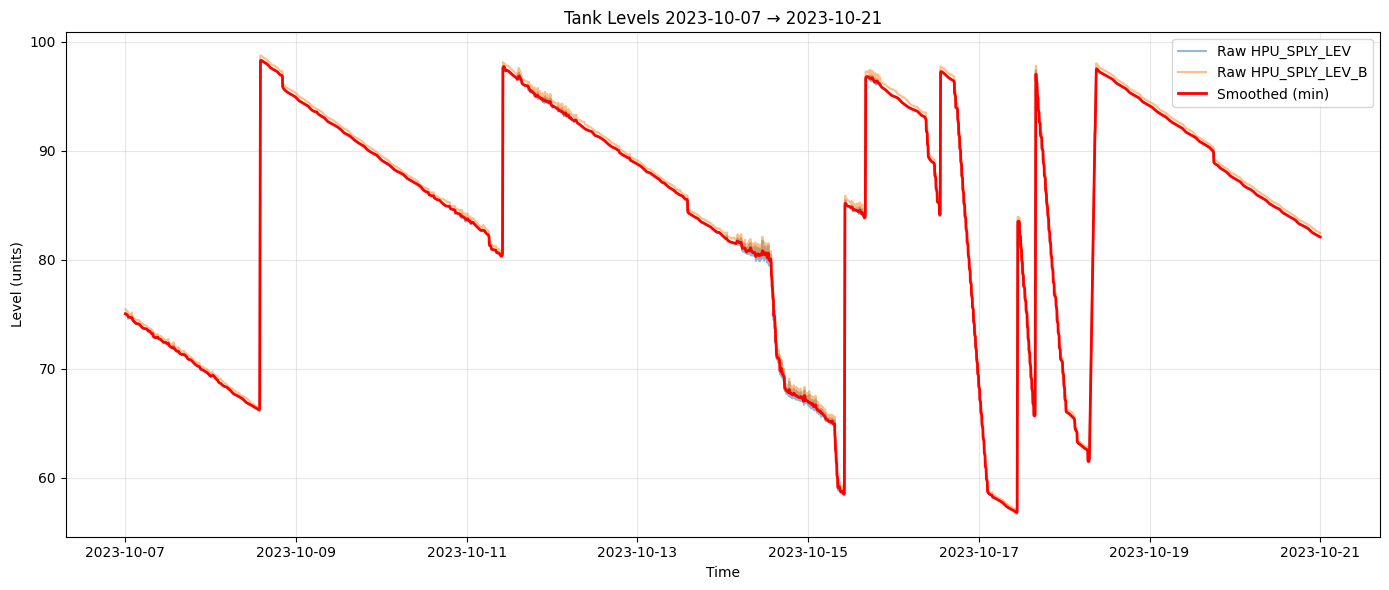

In [ ]:
smoothed_range = plot_tv_smoothed_range_with_raw(df_otter,
                                                 start_day="2023-10-07",
                                                 end_day="2023-10-21",
                                                 combine="min",
                                                 strength=1)

In [ ]:
#  export combined data file as parquet 
import os

# 1) target directory & ensure it exists
out_dir = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output"
os.makedirs(out_dir, exist_ok=True)

# 2) build the output path
out_fname = "SCM2to5_Status.parquet"
out_path  = os.path.join(out_dir, out_fname)

# 3) slice columns 59–69 via iloc[:, 59:70]
df_pcv_cov = df_otter.iloc[:, 59:70]

# 4) write to Parquet (no pandas index)
df_pcv_cov.to_parquet(out_path, engine="pyarrow", index=False)

print(f"✅ Saved {df_pcv_cov.shape[1]} columns × {df_pcv_cov.shape[0]} rows to:\n{out_path}")


✅ Saved 11 columns × 11046261 rows to:
C:\Users\rosst\OneDrive\Control Integrity\Data\Otter at 60 secs with Valves 2004 to 20024\Parquet_Clean_Output\pcv_and_COV_status.parquet
